# LensWord — Model Evaluation

This notebook loads the best saved model and evaluates it on the held-out
test set. It generates a confusion matrix, calculates accuracy and F1 score
per class, and analyzes misclassified examples to understand where the model
struggles. Results are compared against a pretrained HuggingFace model.

Before running: make sure `03_model_training_lensword.ipynb` has been run
first and that `lensword_model.pt` exists inside the `models/` folder.

In [1]:
# Import all necessary libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import pickle
import sys
import os

# Add project root to path so we can import config.py
sys.path.append(os.path.abspath('..'))
from src.config import *

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the test tensors saved from preprocessing notebook
X_test = torch.load('../data/X_test.pt')
y_test = torch.load('../data/y_test.pt')

# Load the vocabulary
with open('../data/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)

print("Test data loaded successfully!")
print(f"Test samples: {X_test.shape[0]}")
print(f"Vocabulary size: {len(word2idx)}")

Test data loaded successfully!
Test samples: 1516
Vocabulary size: 4340


In [3]:
# Rebuild the model architecture
class LensWordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                 num_classes, dropout):
        super(LensWordLSTM, self).__init__()
       
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
       
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True,
                            dropout=dropout)
       
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
   
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

# Initialize model with same settings as training
model = LensWordLSTM(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

# Load the best saved weights
model.load_state_dict(torch.load('../models/lensword_model.pt'))
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [4]:
# Get predictions on the test set
with torch.no_grad():
    outputs = model(X_test)
    predicted = outputs.argmax(dim=1)

# Convert to numpy for sklearn metrics
y_true = y_test.numpy()
y_pred = predicted.numpy()

print("Predictions generated successfully!")
print(f"Total test samples: {len(y_true)}")
print(f"Sample predictions: {y_pred[:10]}")
print(f"Sample true labels: {y_true[:10]}")

Predictions generated successfully!
Total test samples: 1516
Sample predictions: [2 2 1 0 1 1 1 2 2 1]
Sample true labels: [2 2 1 0 1 1 1 2 2 1]


In [5]:
# Calculate overall accuracy and F1 score
label_names = ['Negative', 'Neutral', 'Positive']

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')

print("=" * 45)
print("TEST SET RESULTS - LensWord")
print("=" * 45)
print(f"Overall Accuracy:  {accuracy * 100:.2f}%")
print(f"Macro F1 Score:    {f1_macro * 100:.2f}%")
print("=" * 45)
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

TEST SET RESULTS - LensWord
Overall Accuracy:  88.85%
Macro F1 Score:    88.40%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89       426
     Neutral       0.86      0.85      0.86       415
    Positive       0.90      0.92      0.91       675

    accuracy                           0.89      1516
   macro avg       0.89      0.88      0.88      1516
weighted avg       0.89      0.89      0.89      1516



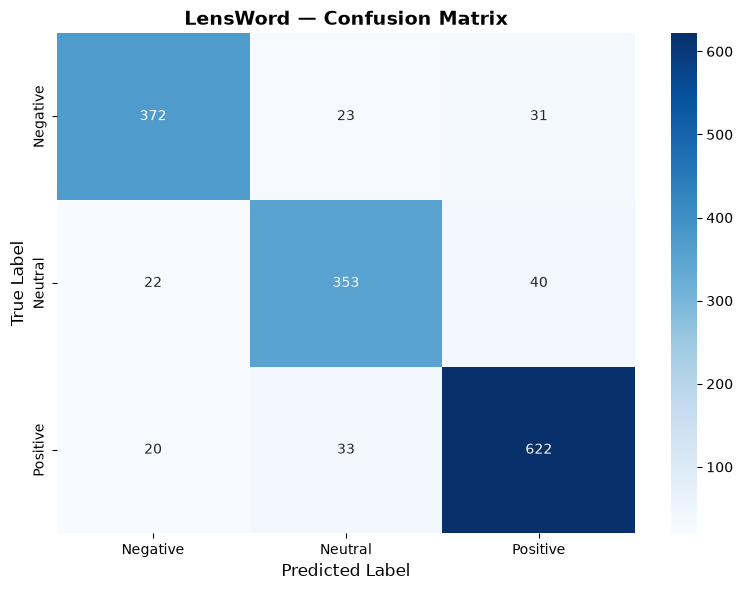

Confusion matrix saved!


In [6]:
# Plot the confusion matrix
label_names = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('LensWord — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png')
plt.show()

print("Confusion matrix saved!")

In [7]:
# Load original cleaned data to show actual review text
import pandas as pd
df = pd.read_csv('../data/amazon_reviews_cleaned.csv')

# Use actual test set size dynamically
test_size = len(y_true)
df_test = df.iloc[-test_size:].copy()
df_test['predicted'] = [['Negative', 'Neutral', 'Positive'][p] for p in y_pred]
df_test['true_label'] = [['Negative', 'Neutral', 'Positive'][t] for t in y_true]
df_test['correct'] = df_test['predicted'] == df_test['true_label']

misclassified = df_test[df_test['correct'] == False]
print(f"Total misclassified: {len(misclassified)} out of {len(df_test)}")
print("\nSample misclassified reviews:")
print("=" * 60)
for _, row in misclassified.head(5).iterrows():
    print(f"Review:    {str(row['verified_reviews'])[:80]}...")
    print(f"True:      {row['true_label']}")
    print(f"Predicted: {row['predicted']}")
    print("-" * 60)

Total misclassified: 169 out of 1516

Sample misclassified reviews:
Review:    Absolutely love it!!!!...
True:      Positive
Predicted: Neutral
------------------------------------------------------------
Review:    No kidding, this place is pretty far from the strip-maybe 25min or did the sat n...
True:      Negative
Predicted: Positive
------------------------------------------------------------
Review:    Been here 2-3 times, our friends dad is a high roller so everything is comped. T...
True:      Neutral
Predicted: Positive
------------------------------------------------------------
Review:    Love it!...
True:      Neutral
Predicted: Positive
------------------------------------------------------------
Review:    Best fast food burger out there. \n\nDouble-double animal style. Crunchiest lett...
True:      Negative
Predicted: Positive
------------------------------------------------------------


In [8]:
# Final evaluation summary with real calculated values
from sklearn.metrics import f1_score, accuracy_score

f1_per_class = f1_score(y_true, y_pred, average=None)

print("=" * 45)
print("EVALUATION SUMMARY - LensWord")
print("=" * 45)
print(f"Test Samples:          {len(y_true)}")
print(f"Correctly Classified:  {(y_true == y_pred).sum()}")
print(f"Misclassified:         {(y_true != y_pred).sum()}")
print(f"Overall Accuracy:      {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"Macro F1 Score:        {f1_score(y_true, y_pred, average='macro') * 100:.2f}%")
print("=" * 45)
print("\nPer Class F1 Scores:")
print(f"  Negative F1:         {f1_per_class[0]:.2f}")
print(f"  Neutral F1:          {f1_per_class[1]:.2f}")
print(f"  Positive F1:         {f1_per_class[2]:.2f}")
print("=" * 45)


EVALUATION SUMMARY - LensWord
Test Samples:          1516
Correctly Classified:  1347
Misclassified:         169
Overall Accuracy:      88.85%
Macro F1 Score:        88.40%

Per Class F1 Scores:
  Negative F1:         0.89
  Neutral F1:          0.86
  Positive F1:         0.91


In [9]:
# Final results comparison table
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Calculate current model results dynamically
current_accuracy = accuracy_score(y_true, y_pred) * 100
current_f1 = f1_score(y_true, y_pred, average='macro') * 100
current_f1_per_class = f1_score(y_true, y_pred, average=None)
current_misclassified = (y_true != y_pred).sum()

results = {
    'Model': [
        'LSTM Before SMOTE',
        'LSTM After SMOTE',
        'LSTM SMOTE + Scheduler (best run)',
        'LSTM + Expanded Dataset (Final)',
        'HuggingFace NLPTown'
    ],
    'Accuracy': ['90.51%', '91.77%', '93.04%',
                 f'{current_accuracy:.2f}%', '87.34%'],
    'Macro F1': ['67.99%', '72.42%', '76.49%',
                 f'{current_f1:.2f}%', '69.27%'],
    'Negative F1': ['0.52', '0.55', '0.62',
                    f'{current_f1_per_class[0]:.2f}', '0.72'],
    'Neutral F1': ['0.56', '0.67', '0.71',
                   f'{current_f1_per_class[1]:.2f}', '0.42'],
    'Positive F1': ['0.95', '0.96', '0.97',
                    f'{current_f1_per_class[2]:.2f}', '0.94'],
    'Misclassified': ['30', '26', '22',
                      f'{current_misclassified}', 'N/A']
}

df_results = pd.DataFrame(results)
df_results.to_csv('../models/results_comparison.csv', index=False)
print(df_results.to_string(index=False))

                            Model Accuracy Macro F1 Negative F1 Neutral F1 Positive F1 Misclassified
                LSTM Before SMOTE   90.51%   67.99%        0.52       0.56        0.95            30
                 LSTM After SMOTE   91.77%   72.42%        0.55       0.67        0.96            26
LSTM SMOTE + Scheduler (best run)   93.04%   76.49%        0.62       0.71        0.97            22
  LSTM + Expanded Dataset (Final)   88.85%   88.40%        0.89       0.86        0.91           169
              HuggingFace NLPTown   87.34%   69.27%        0.72       0.42        0.94           N/A
